# Accounting-based analysis

Notebook scaffold — add sections and code as needed.

In [1]:
import pandas as pd
from accounting_decomp import generate_synthetic_mcd_data, run_accounting_decomp

df = generate_synthetic_mcd_data()

In [2]:
df.columns

Index(['week_start', 'year', 'week_num', 'quarter', 'month', 'channel',
       'daypart', 'menu_type', 'promo_type', 'gc', 'offer_gc', 'reward_gc',
       'units', 'original_price_sales', 'discount_amount', 'net_sales',
       'is_offer', 'is_reward', 'is_bogo', 'ac', 'upt', 'aur',
       'original_price_per_unit', 'discount_per_unit'],
      dtype='object')

In [3]:

outputs = run_accounting_decomp(
    df,
    hierarchy_map={
        "gc": [
            ["is_offer"],
            ["channel", "daypart"],
            ["daypart", "channel"],
        ],
        "sales": [
            ["channel", "daypart"],
            ["daypart", "channel"],
        ],
        "ac": [
            ["channel", "daypart"],
            ["daypart", "channel"],
            ],
        "upt": [
            # ["channel", "daypart"],
            [
             "daypart", 
             "channel"
             ],
            ],
        "aur": [
            ["channel"], 
            ["daypart"]
            ],
        "original_price_per_unit": [
            ["channel"], 
            # ["daypart"]
            ],
        "discount_per_unit": [
            ["channel"], 
            # ["daypart"]
            ],
    },
)



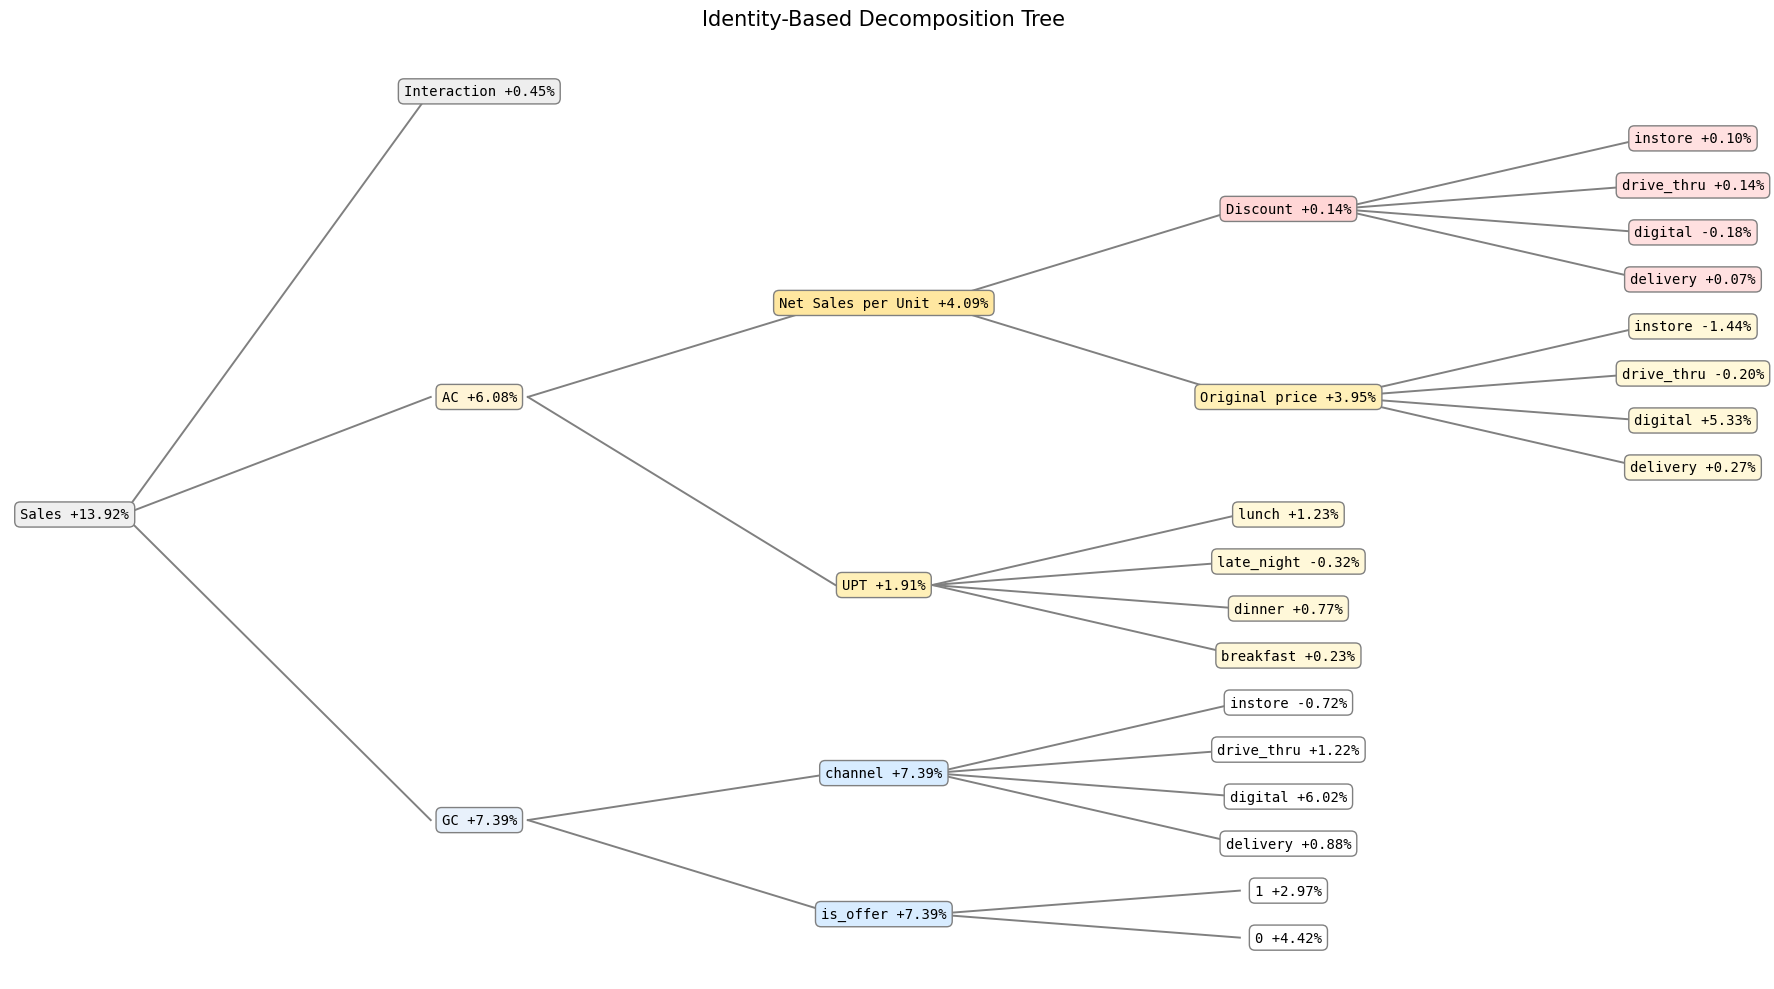

In [4]:
from accounting_decomp import generate_synthetic_mcd_data, run_accounting_decomp
from accounting_tree_visual import build_sales_decomposition_tree, plot_decomposition_tree


root = build_sales_decomposition_tree(
    df,
    outputs,
    gc_domains=(
        "is_offer", 
        # "daypart", 
        "channel"
                ),   # or ("daypart",) or ("channel",)
    gc_group_labels=True,
)


plot_decomposition_tree(root, 
                        # save_path="sales_decomp_tree.png", 
                        show=True,
                        show_meta_lines=False)

In [7]:
bridge = outputs["sales_gc_ac_bridge"]
gc_details = outputs["additive__gc"]
ac_details = outputs["ratio__ac"]
upt_df = outputs["ratio__upt"]
aur_df = outputs["ratio__aur"]

gpu_details = outputs["ratio__original_price_per_unit"]
discount_details = outputs["ratio__discount_per_unit"]


In [4]:
# display(bridge)
# display(gc_details)
# display(ac_details)
# display(upt_df)
# display(aur_df)
# display(gpu_details)
# display(discount_details)

In [3]:
upt_df = outputs["ratio__upt"]
aur_df = outputs["ratio__aur"]
gpu_details = outputs["ratio__original_price_per_unit"]
discount_details = outputs["ratio__discount_per_unit"]

# upt_detail = upt_df[
#     (upt_df["hierarchy_name"] == "promo_type > channel") &
#     (upt_df["level"] == 2)
# ].copy()

# upt_detail = upt_detail.sort_values("total_pct_of_root_metric", ascending=False)

# print(upt_detail[
#     [
#         "path",
#         "ratio_base",
#         "ratio_current",
#         "mix_pct_of_root_metric",
#         "within_pct_of_root_metric",
#         "total_pct_of_root_metric",
#     ]
# ])